In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/jlee295/cenp/CAFEMOL/analyses/EtD")
WORKING_DIR = Path("/Users/jlee295/cenp/CAFEMOL/analyses/EtD/convergence_analysis")

SYSTEMS = [
    # Row 1
    "H3",
    "exnotailH3",
    "cenpa",
    "exnotailcenpa",

    # Row 2
    "H3withcenpahelix",
    "H3withcenpa_latch_helix",
    "cenpawithH3helix",
    "cenpawithH3_latch_helix",

    # Row 3
    "H3withcenpalatch",
    "ltH3core",
    "cenpawithH3latch",
    "ltcenpacore",

    # Row 4
    "stH3core",
    "thruhelixH3",
    "stcenpacore",
    "thruhelixcenpa"
]

SYSTEM_TITLES = {
    "H3": "H3",
    "exnotailH3": "Tailless H3",
    "cenpa": "CENP-A",
    "exnotailcenpa": "Tailless CENP-A",
    "H3withcenpahelix": r"H3 with CENP-A$_{\mathrm{\alpha N}}$",
    "H3withcenpa_latch_helix": r"CENP-A$_{\mathrm{Latch+\alpha N}}$H3$_{\mathrm{Core}}$",
    "cenpawithH3helix": r"CENP-A with H3$_{\mathrm{\alpha N}}$",
    "cenpawithH3_latch_helix": r"H3$_{\mathrm{Latch+\alpha N}}$CENP-A$_{\mathrm{Core}}$",
    "H3withcenpalatch": r"H3 with CENP-A$_{\mathrm{Latch}}$",
    "ltH3core": r"CENP-A$_{\mathrm{Tail+Latch}}$H3$_{\mathrm{Core}}$",
    "cenpawithH3latch": r"CENP-A with H3$_{\mathrm{Latch}}$",
    "ltcenpacore": r"H3$_{\mathrm{Tail+Latch}}$CENP-A$_{\mathrm{Core}}$",
    "stH3core": r"CENP-A$_{\mathrm{Tail}}$H3$_{\mathrm{Core}}$",
    "thruhelixH3": r"CENP-A$_{\mathrm{Tail+Latch+\alpha N}}$H3$_{\mathrm{Core}}$",
    "stcenpacore": r"H3$_{\mathrm{Tail}}$CENP-A$_{\mathrm{Core}}$",
    "thruhelixcenpa": r"H3$_{\mathrm{Tail+Latch+\alpha N}}$CENP-A$_{\mathrm{Core}}$"
}

RUNS = [1, 2, 3, 4]

# EtD histogram settings
BINS = np.arange(25, 107, 2)

# Compare cumulative trajectory fractions
FRACTIONS = np.arange(0.1, 1.0, 0.1)

In [18]:
def load_etd(filename):
    data = np.loadtxt(filename, comments=("#", "@", "&"))

    return data[:, 1]

etd_data = {}

for system in SYSTEMS:

    etd_data[system] = {}

    for run in RUNS:

        entry_file = BASE_DIR / f"{system}-dist-etd_entry{run}.dat"
        exit_file = BASE_DIR / f"{system}-dist-etd_exit{run}.dat"

        entry_values = load_etd(entry_file)
        exit_values = load_etd(exit_file)

        etd_data[system][run] = {"Entry": entry_values, "Exit": exit_values}

        print(
            f"{system:28s} Run {run}: "
            f"Entry = {len(entry_values)}, "
            f"Exit = {len(exit_values)}"
        )

H3                           Run 1: Entry = 100005, Exit = 100005
H3                           Run 2: Entry = 100005, Exit = 100005
H3                           Run 3: Entry = 100005, Exit = 100005
H3                           Run 4: Entry = 100005, Exit = 100005
exnotailH3                   Run 1: Entry = 100005, Exit = 100005
exnotailH3                   Run 2: Entry = 100005, Exit = 100005
exnotailH3                   Run 3: Entry = 100005, Exit = 100005
exnotailH3                   Run 4: Entry = 100005, Exit = 100005
cenpa                        Run 1: Entry = 100005, Exit = 100005
cenpa                        Run 2: Entry = 100005, Exit = 100005
cenpa                        Run 3: Entry = 100005, Exit = 100005
cenpa                        Run 4: Entry = 100005, Exit = 100005
exnotailcenpa                Run 1: Entry = 100005, Exit = 100005
exnotailcenpa                Run 2: Entry = 100005, Exit = 100005
exnotailcenpa                Run 3: Entry = 100005, Exit = 100005
exnotailce

In [19]:
def probability_histogram(values):
    counts, _ = np.histogram(values, bins=BINS)

    counts = counts.astype(float)

    if counts.sum() == 0:
        return counts

    return counts / counts.sum()


def js_divergence(p, q):
    """Jensen-Shannon divergence using log base 2.
    JSD = 0 means identical distributions.
    Larger values mean greater difference.
    """

    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)

    p_mask = p > 0
    q_mask = q > 0

    kl_pm = np.sum(p[p_mask] * np.log2(p[p_mask] / m[p_mask]))
    kl_qm = np.sum(q[q_mask] * np.log2(q[q_mask] / m[q_mask]))

    return 0.5 * (kl_pm + kl_qm)

In [20]:
rows = []

for system in SYSTEMS:

    for run in RUNS:

        for side in ["Entry", "Exit"]:

            values = etd_data[system][run][side]
            n_frames = len(values)

            # Final full-trajectory distribution
            final_hist = probability_histogram(values)

            for fraction in FRACTIONS:

                end_frame = int(round(n_frames * fraction))
                cumulative_values = values[:end_frame]
                cumulative_hist = probability_histogram(cumulative_values)
                jsd = js_divergence(cumulative_hist, final_hist)

                rows.append({
                    "system": system,
                    "run": run,
                    "side": side,
                    "fraction": fraction,
                    "percent": fraction * 100,
                    "JSD": jsd
                })

cumulative_jsd = pd.DataFrame(rows)
cumulative_jsd.head()

,system,run,side,fraction,percent,JSD
0,H3,1,Entry,0.1,10.0,0.005124
1,H3,1,Entry,0.2,20.0,0.001496
2,H3,1,Entry,0.3,30.0,0.001078
3,H3,1,Entry,0.4,40.0,0.000786
4,H3,1,Entry,0.5,50.0,0.000827


In [21]:
jsd_summary = (cumulative_jsd.groupby(["system", "side", "percent"])
    .agg(mean_JSD=("JSD", "mean"), sem_JSD=("JSD", "sem")).reset_index())

jsd_summary.head()

,system,side,percent,mean_JSD,sem_JSD
0,H3,Entry,10.0,0.004521,0.001226
1,H3,Entry,20.0,0.001029,0.000157
2,H3,Entry,30.0,0.000856,0.000146
3,H3,Entry,40.0,0.000657,0.000201
4,H3,Entry,50.0,0.000417,0.000158


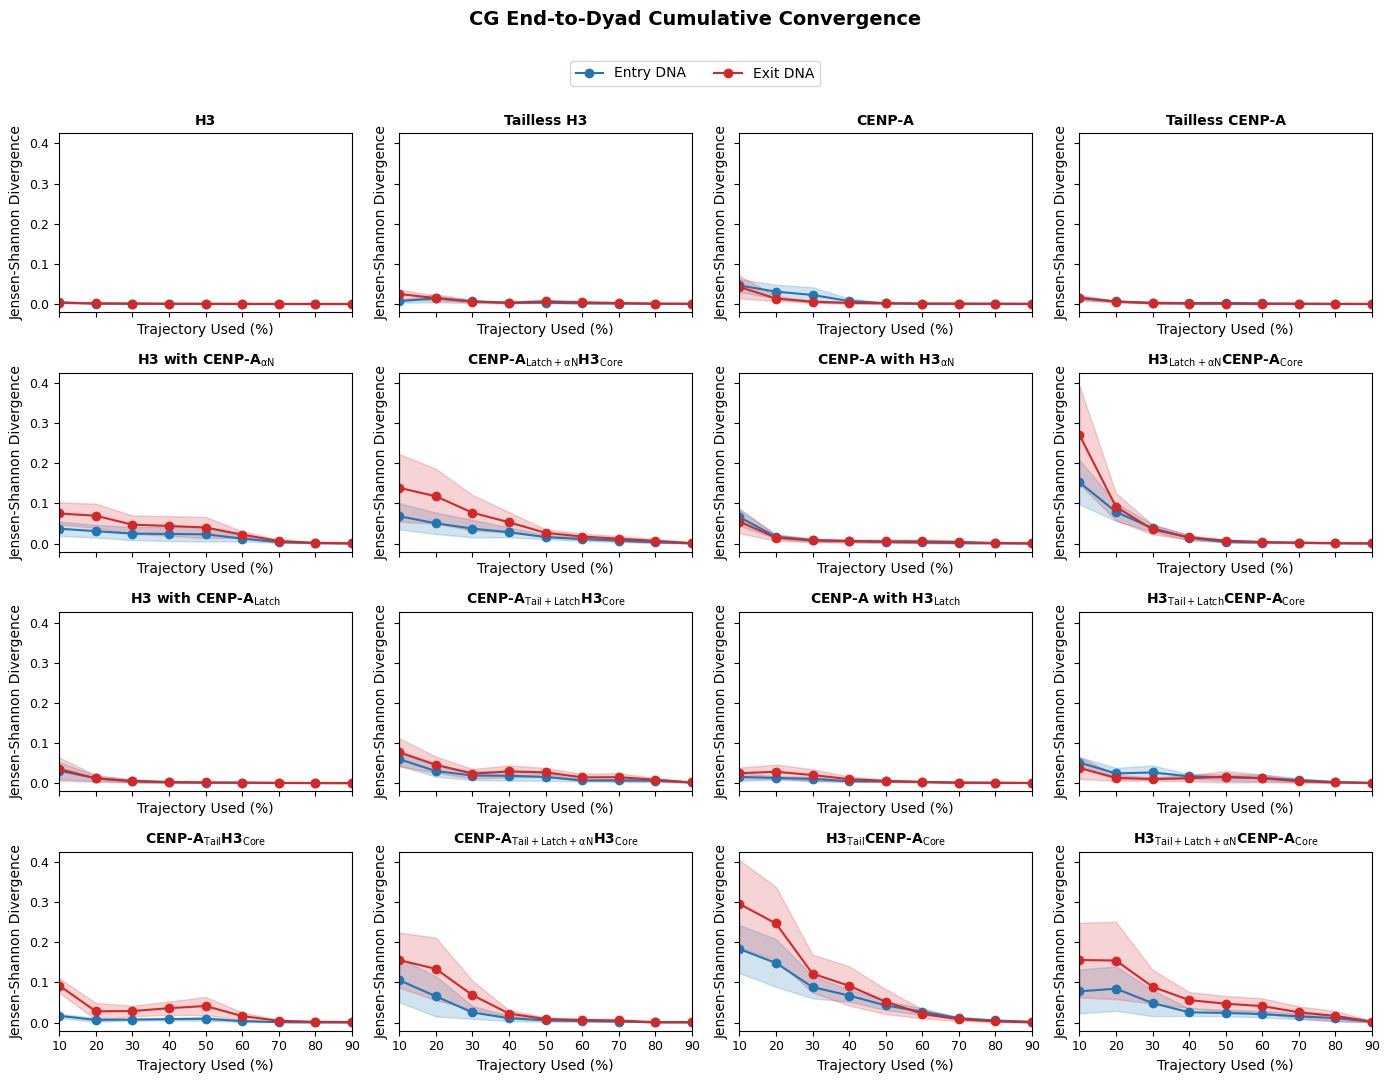

In [29]:
fig, axes = plt.subplots(4, 4, figsize=(14, 11), sharex=True, sharey=True)

axes = axes.flatten()

for ax, system in zip(axes, SYSTEMS):

    # ENTRY
    entry = jsd_summary[(jsd_summary["system"] == system) & (jsd_summary["side"] == "Entry")]

    x = entry["percent"].to_numpy()
    y = entry["mean_JSD"].to_numpy()
    sem = entry["sem_JSD"].to_numpy()

    ax.plot(x, y, color="C0", marker="o", label="Entry DNA")
    ax.fill_between(x, y - sem, y + sem, color="C0", alpha=0.2)

    # EXIT
    exit_data = jsd_summary[(jsd_summary["system"] == system) & (jsd_summary["side"] == "Exit")]

    x = exit_data["percent"].to_numpy()
    y = exit_data["mean_JSD"].to_numpy()
    sem = exit_data["sem_JSD"].to_numpy()

    ax.plot(x, y, color="C3", marker="o", label="Exit DNA")
    ax.fill_between(x, y - sem, y + sem, color="C3", alpha=0.2)

    # FORMATTING
    ax.set_xlim(10, 90)
    ax.set_xticks(np.arange(10, 91, 10))
    ax.set_xlabel("Trajectory Used (%)", fontsize=10)
    ax.set_ylabel("Jensen-Shannon Divergence", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.set_title(SYSTEM_TITLES[system], fontsize=10, fontweight="bold")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=2, fontsize=10)
fig.suptitle("CG End-to-Dyad Cumulative Convergence", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(WORKING_DIR / "CG_EtD_cumulative_convergence.pdf")
plt.savefig(WORKING_DIR / "CG_EtD_cumulative_convergence.png")

plt.show()

In [30]:
cumulative_jsd.to_csv(
    WORKING_DIR / "CG_EtD_cumulative_JSD_per_run.csv",
    index=False
)

jsd_summary.to_csv(
    WORKING_DIR / "CG_EtD_cumulative_JSD_mean_SEM.csv",
    index=False
)

print("Saved cumulative convergence results.")

Saved cumulative convergence results.
